In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import joblib

df    = pd.read_csv("data/ml_ready.csv")
model = joblib.load("models/xgboost_model.pkl")

feature_cols = [c for c in df.columns
                if c not in ["distressed","company","sector"]]
X = df[feature_cols]

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

print("SHAP values computed. Shape:", shap_values.shape)
print("Ready for visualization!")


SHAP values computed. Shape: (350, 22)
Ready for visualization!


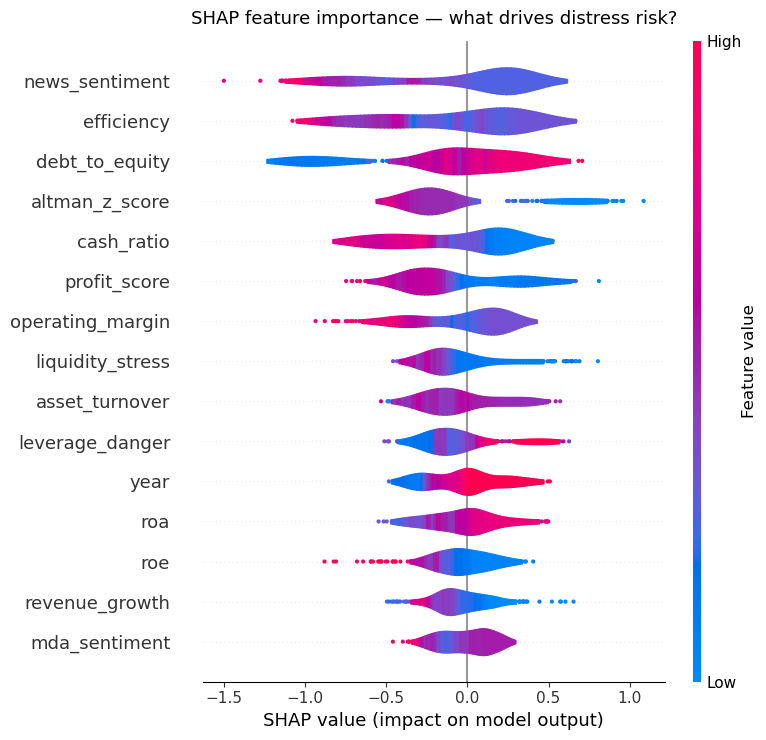

Saved: reports/05_shap_summary.png


In [2]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X, plot_type="violin",
                  show=False, max_display=15)
plt.title("SHAP feature importance — what drives distress risk?",
          fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("reports/05_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reports/05_shap_summary.png")


Explaining: BetaInc
Risk score: 57.6% — DISTRESSED


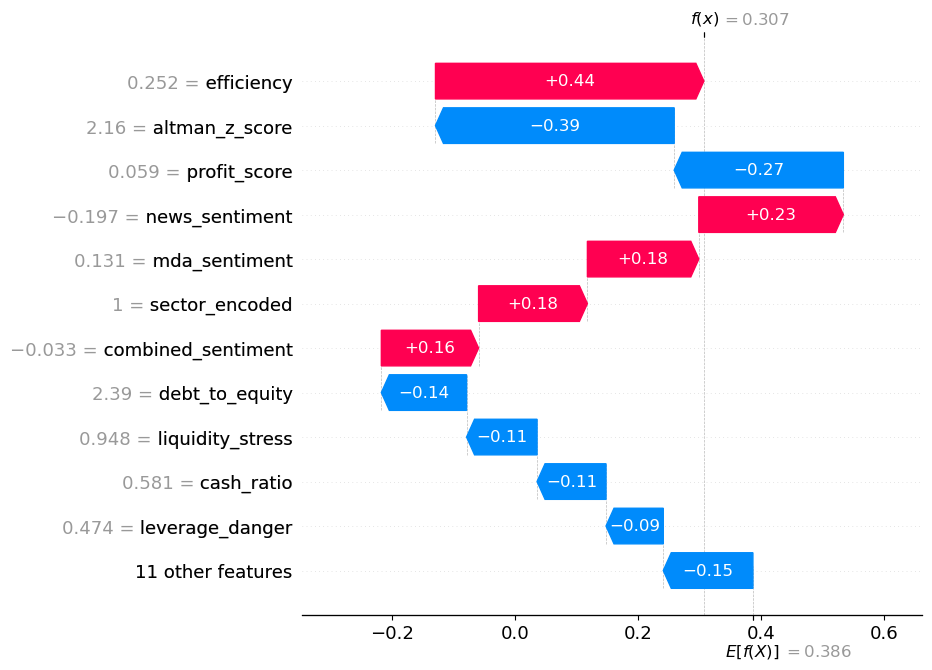

In [3]:
# Find a distressed company to explain
distressed_idx = df[df["distressed"]==1].index[0]
company_name   = df.loc[distressed_idx, "company"]
risk_score     = model.predict_proba(X)[distressed_idx, 1]

print(f"Explaining: {company_name}")
print(f"Risk score: {risk_score:.1%} — DISTRESSED")

# Waterfall chart for this company
shap.waterfall_plot(
    shap.Explanation(
        values       = shap_values[distressed_idx],
        base_values  = explainer.expected_value,
        data         = X.iloc[distressed_idx],
        feature_names= feature_cols
    ),
    max_display=12,
    show=True
)


In [4]:
import pandas as pd

# Predict risk probabilities
risk_scores = model.predict_proba(X)[:, 1]

# Build scorecard
scorecard = df[["company", "sector", "year", "distressed"]].copy()

scorecard["risk_score"] = (risk_scores * 100).round(1)

# Risk categories
scorecard["risk_level"] = pd.cut(
    scorecard["risk_score"],
    bins=[0, 30, 60, 100],
    labels=["Low", "Medium", "High"]
)

# Convert actual label
scorecard["actual_status"] = scorecard["distressed"].map(
    {0: "Healthy", 1: "Distressed"}
)

# Sort by risk
scorecard = scorecard.sort_values("risk_score", ascending=False)

# Save file
scorecard.to_csv("reports/risk_scorecard.csv", index=False)

# Output top results
print("TOP 10 HIGHEST RISK COMPANIES")
print("="*60)

print(
    scorecard[
        ["company", "sector", "risk_score", "risk_level", "actual_status"]
    ].head(10).to_string(index=False)
)

TOP 10 HIGHEST RISK COMPANIES
    company        sector  risk_score risk_level actual_status
 EpsilonMfg    Technology   98.900002       High    Distressed
    BetaInc       Finance   98.699997       High    Distressed
   ChiHotel       Finance   98.400002       High    Distressed
  RhoInsure   Real Estate   98.400002       High    Distressed
 EpsilonMfg   Real Estate   98.199997       High    Distressed
 KappaPharm Manufacturing   98.099998       High    Distressed
 EpsilonMfg        Retail   98.000000       High    Distressed
  MuConsult Manufacturing   98.000000       High    Distressed
 EpsilonTwo   Real Estate   97.900002       High    Distressed
OmicronReal        Energy   97.500000       High    Distressed
